In [166]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [167]:
df = pd.read_csv("Datasets/Algerian_forest_fires_train.csv")

In [168]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [169]:
# independent and Dependant features
X = df.drop("FWI", axis=1)
y = df["FWI"]

In [170]:
# Train Test Split
from sklearn.model_selection import train_test_split

In [171]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [172]:
# Feature Selection based on correlation
crr = X_train.corr()

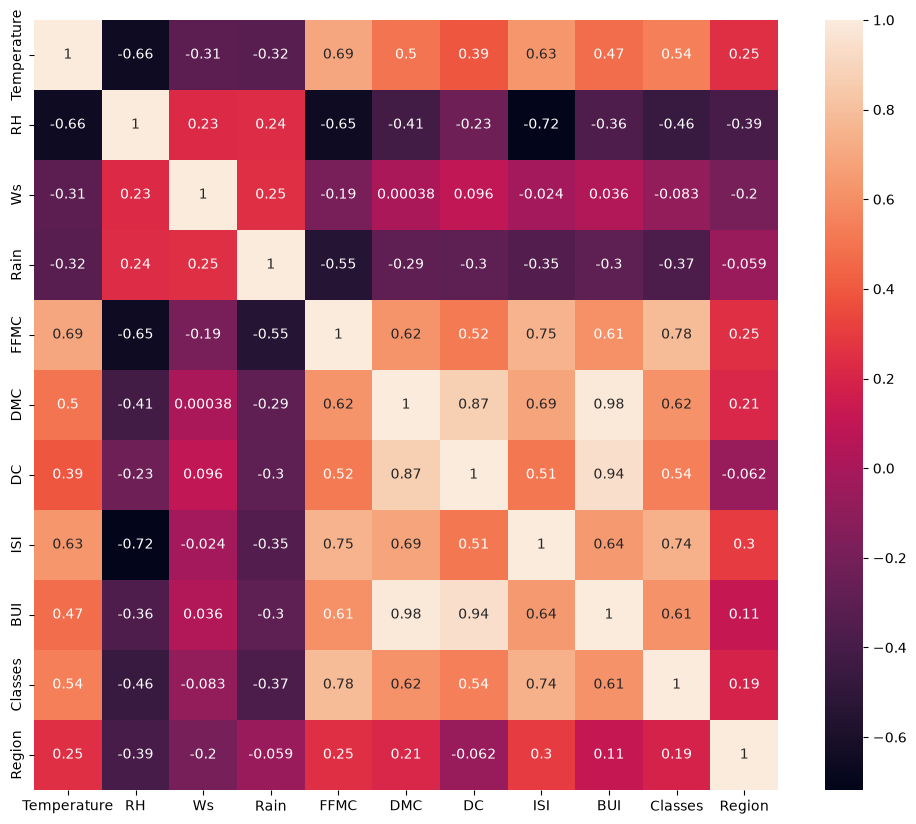

In [173]:
# Checking for multicollinearity
plt.figure(figsize=(12, 10))
sns.heatmap(crr, annot=True)
plt.show()

In [174]:
def correlation(data, thresh):
    col_corr = set()
    corr_matrix = data.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > thresh:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [175]:
drop_feature = correlation(X_train, 0.85)

In [176]:
# Drop features whose correlation is beyond thershold
X_train.drop(drop_feature, axis=1, inplace=True)
X_test.drop(drop_feature, axis=1, inplace=True)

In [177]:
# Feature Scaling or Standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [178]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [179]:
X_train_scaled

array([[-0.84284248,  0.78307967,  1.29972026, ..., -0.62963326,
        -1.10431526, -0.98907071],
       [-0.30175842,  0.64950844, -0.59874754, ..., -0.93058524,
        -1.10431526,  1.01105006],
       [ 2.13311985, -2.08870172, -0.21905398, ...,  2.7271388 ,
         0.90553851,  1.01105006],
       ...,
       [-1.9250106 ,  0.9166509 ,  0.54033314, ..., -1.06948615,
        -1.10431526, -0.98907071],
       [ 0.50986767, -0.21870454,  0.16063958, ...,  0.5973248 ,
         0.90553851,  1.01105006],
       [-0.57230045,  0.98343651,  2.05910739, ..., -0.86113478,
        -1.10431526, -0.98907071]], shape=(182, 9))

Text(0.5, 1.0, 'X_train After Standardization')

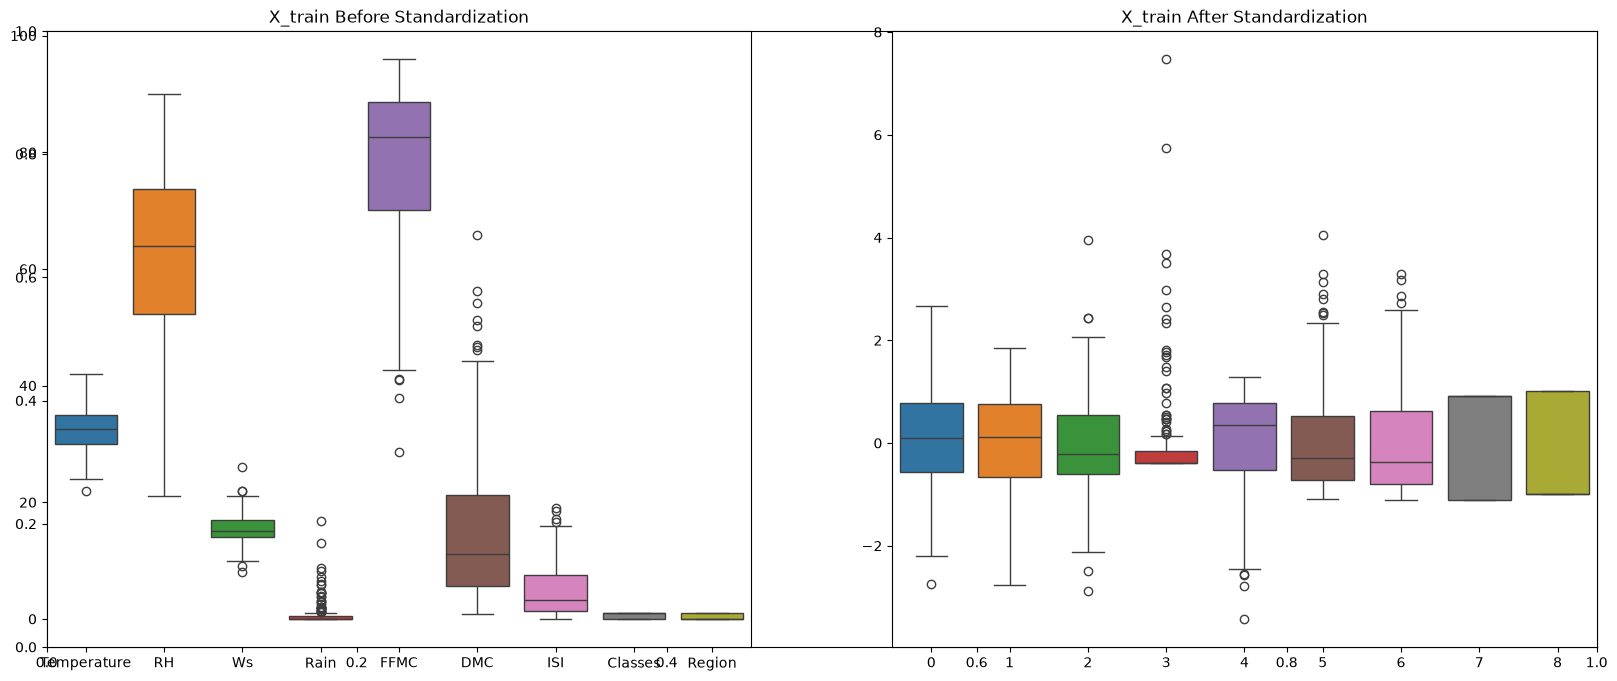

In [180]:
# Box plot to understand Effect of Standard Scaler
plt.subplots(figsize=(20, 8))
plt.subplot(1, 2, 1)
sns.boxplot(X_train)
plt.title("X_train Before Standardization")
plt.subplot(1, 2, 2)
sns.boxplot(X_train_scaled)
plt.title("X_train After Standardization")

# Linear Regression Model


Mean Absolute Error: 0.5677281423655818
R Square Score:  0.9837622041705885


<Axes: ylabel='FWI'>

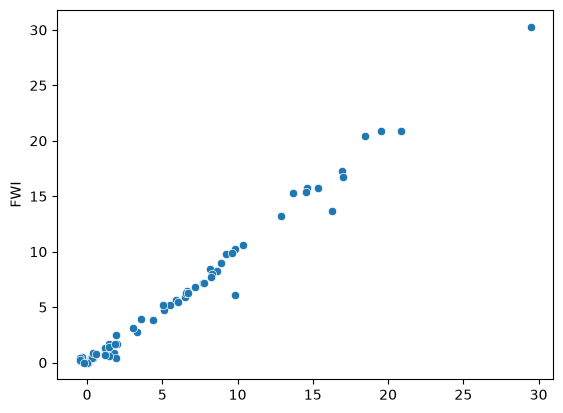

In [181]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
y_pred = lin_reg.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean Absolute Error:", mae)
print("R Square Score: ", score)

sns.scatterplot(x=y_pred, y=y_test)

# Lasso Regression Model


Mean Absolute Error: 1.1480776829776165
R Square Score:  0.947496008628597


<Axes: ylabel='FWI'>

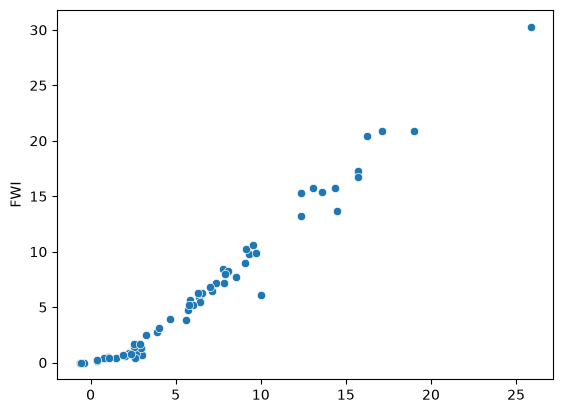

In [182]:
from sklearn.linear_model import Lasso

lso = Lasso()
lso.fit(X_train_scaled, y_train)
y_pred = lso.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean Absolute Error:", mae)
print("R Square Score: ", score)

sns.scatterplot(x=y_pred, y=y_test)

# Lasso Regression with Cross Validation


In [183]:
from sklearn.linear_model import LassoCV

lsocv = LassoCV(cv=5)  # Giving cv = 5 to find best alpha value for regularisation
lsocv.fit(X_train_scaled, y_train)
y_pred = lsocv.predict(X_test_scaled)


In [184]:
lsocv.alpha_

np.float64(0.06531886959090867)

In [185]:
lsocv.alphas_

array([7.00392828, 6.53188696, 6.09165964, 5.68110217, 5.2982149 ,
       4.94113294, 4.60811712, 4.29754545, 4.00790527, 3.73778587,
       3.48587161, 3.25093553, 3.03183336, 2.82749794, 2.63693404,
       2.45921351, 2.29347075, 2.1388985 , 1.9947439 , 1.86030483,
       1.73492652, 1.61799827, 1.50895061, 1.40725239, 1.31240828,
       1.22395636, 1.1414658 , 1.06453482, 0.99278874, 0.9258781 ,
       0.86347701, 0.80528155, 0.75100827, 0.70039283, 0.6531887 ,
       0.60916596, 0.56811022, 0.52982149, 0.49411329, 0.46081171,
       0.42975455, 0.40079053, 0.37377859, 0.34858716, 0.32509355,
       0.30318334, 0.28274979, 0.2636934 , 0.24592135, 0.22934707,
       0.21388985, 0.19947439, 0.18603048, 0.17349265, 0.16179983,
       0.15089506, 0.14072524, 0.13124083, 0.12239564, 0.11414658,
       0.10645348, 0.09927887, 0.09258781, 0.0863477 , 0.08052816,
       0.07510083, 0.07003928, 0.06531887, 0.0609166 , 0.05681102,
       0.05298215, 0.04941133, 0.04608117, 0.04297545, 0.04007

Mean Absolute Error: 0.6448021187162611
R Square Score:  0.9807232073347063


<Axes: ylabel='FWI'>

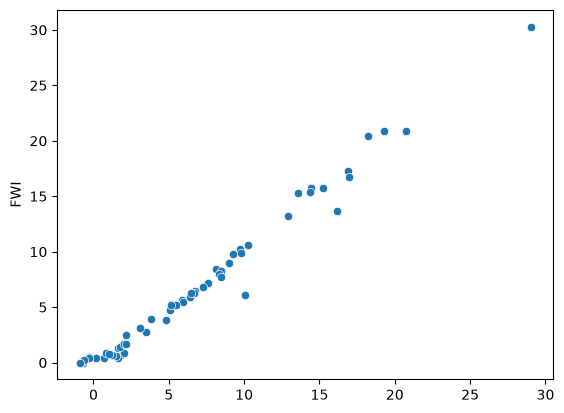

In [186]:
mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R Square Score: ", score)

sns.scatterplot(x=y_pred, y=y_test)

# Ridge Regression Model


In [187]:
from sklearn.linear_model import Ridge

rdg = Ridge()
rdg.fit(X_train_scaled, y_train)
y_pred = rdg.predict(X_test_scaled)

Mean Absolute Error: 0.5811107674166778
R Square Score:  0.9833489534582402


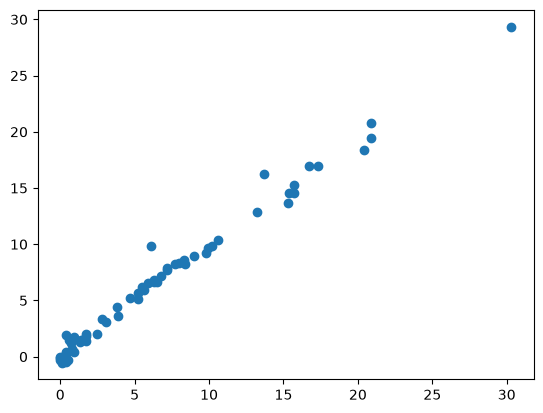

In [188]:
mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean Absolute Error:", mae)
print("R Square Score: ", score)
plt.scatter(y_test, y_pred)

# Ridge Regression with Cross Validation


In [189]:
from sklearn.linear_model import RidgeCV

rdgcv = RidgeCV(cv=5)  # Giving cv = 5 to find best alpha value for regularisation
rdgcv.fit(X_train_scaled, y_train)
y_pred = rdgcv.predict(X_test_scaled)

In [190]:
rdgcv.alpha_

np.float64(10.0)

In [191]:
rdgcv.alphas

(0.1, 1.0, 10.0)

Mean Absolute Error: 0.7684899873977278
R Square Score:  0.9765384147340441


<Axes: ylabel='FWI'>

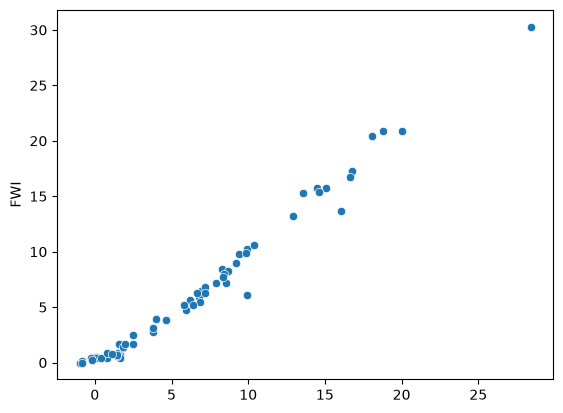

In [192]:
mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R Square Score: ", score)

sns.scatterplot(x=y_pred, y=y_test)

# ElasticNet Regression Model


Mean Absolute Error: 1.873452537497212
R Square Score:  0.8747265847821615


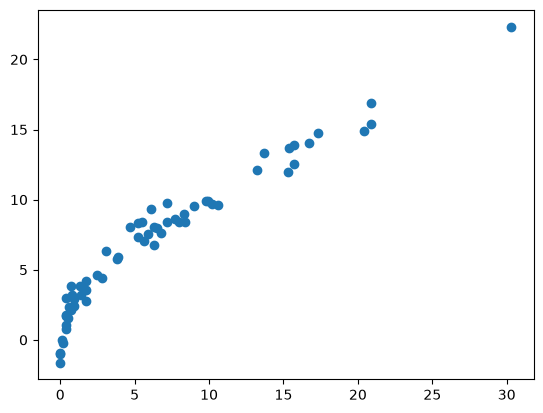

In [193]:
from sklearn.linear_model import ElasticNet

elsnt = ElasticNet()
elsnt.fit(X_train_scaled, y_train)
y_pred = elsnt.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean Absolute Error:", mae)
print("R Square Score: ", score)
plt.scatter(y_test, y_pred)

# ElasticNet Regression with Cross Validation

In [ ]:
from sklearn.linear_model import ElasticNetCV

elsntcv = ElasticNetCV(cv=5)
elsntcv.fit(X_train_scaled, y_train)
y_pred = elsntcv.predict(X_test_scaled)

In [195]:
elsntcv.alpha_

np.float64(0.04277796994780591)

In [196]:
elsntcv.alphas_

array([14.00785657, 13.06377392, 12.18331928, 11.36220434, 10.59642979,
        9.88226589,  9.21623424,  8.5950909 ,  8.01581054,  7.47557174,
        6.97174322,  6.50187106,  6.06366671,  5.65499587,  5.27386808,
        4.91842702,  4.5869415 ,  4.27779699,  3.98948779,  3.72060967,
        3.46985303,  3.23599655,  3.01790121,  2.81450477,  2.62481657,
        2.44791272,  2.28293159,  2.12906964,  1.98557748,  1.8517562 ,
        1.72695403,  1.61056311,  1.50201654,  1.40078566,  1.30637739,
        1.21833193,  1.13622043,  1.05964298,  0.98822659,  0.92162342,
        0.85950909,  0.80158105,  0.74755717,  0.69717432,  0.65018711,
        0.60636667,  0.56549959,  0.52738681,  0.4918427 ,  0.45869415,
        0.4277797 ,  0.39894878,  0.37206097,  0.3469853 ,  0.32359965,
        0.30179012,  0.28145048,  0.26248166,  0.24479127,  0.22829316,
        0.21290696,  0.19855775,  0.18517562,  0.1726954 ,  0.16105631,
        0.15020165,  0.14007857,  0.13063774,  0.12183319,  0.11

In [198]:
elsntcv.l1_ratio

0.5

Mean Absolute Error: 0.6690919857152395
R Square Score:  0.980613642711414


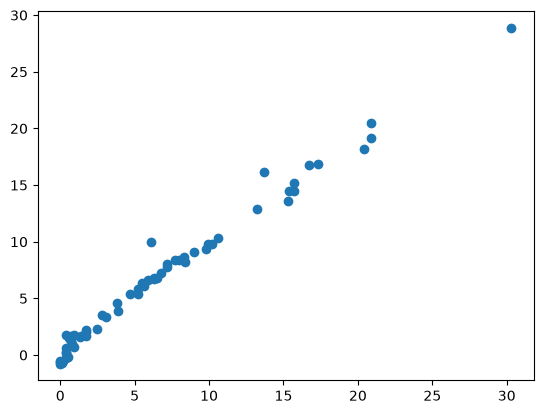

In [197]:
mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean Absolute Error:", mae)
print("R Square Score: ", score)
plt.scatter(y_test, y_pred)